# Ridge pipeline — the full code → result through-line (HAR baseline)

**The trust contract.** Each stage below walks the **live call graph over `src/`** and
shows *every* function and class that does the work — not just the outer wrapper, but the
helpers it calls, and the helpers *they* call, transitively, deduped. The set is computed
by parsing the imported modules' source (`ast`), so **it cannot hide a deep function**:
if `src/` gains a helper on the path, it shows up here automatically. Then the same
functions run on the real data.

So the code you read **is** the complete set of code that executes — ~1,200 lines across
~25 `src/` defs — ending at **HAR QLIKE = 0.13460**. **Each function is its own
collapsible `<details>`** (click the ▸ on a row to fold/unfold that layer), so the whole
tree is present but you expand only what you want to audit. `src/` is the source of
truth; this notebook is a complete, drift-proof window onto it.

In [1]:
import ast, html, inspect, importlib, os, sys, textwrap
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Markdown

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "src" / "models" / "ridge.py").exists() and (q / "data").exists():
            return q
    raise FileNotFoundError("repo root not found from " + str(start))
REPO = find_repo(Path.cwd()); os.chdir(REPO); sys.path.insert(0, str(REPO))

# Quiet tqdm: the walk-forward's progress bar renders as repeated lines under headless /
# VS Code execution. Patch the tqdm class (applies even though MultiStageBacktest already
# imported it) so the through-line output stays clean.
import tqdm as _tqdm
from functools import partialmethod
_tqdm.tqdm.__init__ = partialmethod(_tqdm.tqdm.__init__, disable=True)

# ── live call-graph walker over src/ ──────────────────────────────────────────
# _refs(obj): the src functions/classes obj directly CALLS or INSTANTIATES (Name(...)
# calls). Attribute calls (.run()/.fit()) are skipped — a class is shown whole, so its
# methods come with it, and this dodges method-name vs module-global collisions.
def _refs(obj):
    try: tree = ast.parse(textwrap.dedent(inspect.getsource(obj)))
    except (OSError, TypeError, SyntaxError): return []
    g = vars(importlib.import_module(obj.__module__)); out, seen = [], set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
            nm = node.func.id
            if nm in seen: continue
            seen.add(nm); t = g.get(nm)
            if t is not None and (getattr(t, "__module__", "") or "").startswith("src") \
               and (inspect.isfunction(t) or inspect.isclass(t)):
                out.append(t)
    return out

def call_tree(entry):           # transitive closure, dependencies first
    seen, order = set(), []
    def visit(o):
        if o in seen: return
        seen.add(o)
        for c in _refs(o): visit(c)
        order.append(o)
    visit(entry); return order

_SHOWN = set()                  # dedup across stages — each def shown once
OPEN_BY_DEFAULT = False         # start every layer folded; set True to render <details open>
def show_tree(entry):
    # One collapsible <details> per src def, deepest-dependency first, entry first within
    # the stage. The ```python fence inside (blank-line separated) stays theme-highlighted
    # by the front-end (markdown-it / VS Code), so each layer folds AND follows your theme.
    tree = call_tree(entry)
    ordered = [entry] + [f for f in tree if f is not entry]
    fresh = [f for f in ordered if f not in _SHOWN]; _SHOWN.update(fresh)
    op = " open" if OPEN_BY_DEFAULT else ""
    parts = []
    for f in fresh:
        path = f.__module__.replace("src.", "src/").replace(".", "/") + ".py"
        try:
            sig = ("class " + f.__name__) if inspect.isclass(f) \
                else ("def " + f.__name__ + str(inspect.signature(f)))
        except (ValueError, TypeError):
            sig = f.__qualname__
        summary = html.escape(f"{path}  ·  {sig}")
        body = "```python\n" + textwrap.dedent(inspect.getsource(f)).rstrip() + "\n```"
        parts.append(f"<details{op}>\n<summary><code>{summary}</code></summary>\n\n{body}\n\n</details>")
    return Markdown("\n\n".join(parts))

# the real pipeline functions (same objects run.py / the cluster import)
from src.backtest.executor import load_and_transform, _build_har_and_calendar, _backtest_and_save
from src.features.extractors.har import resolve_har_lags
from src.models.ridge import fit_predict_ridge
from src.evaluation.metrics import (calculate_metrics, plot_mz_scatter,
                                    plot_y_yhat_timeseries, mz_regression)
import matplotlib.pyplot as plt
print("repo:", REPO)

repo: C:\Users\james\CC Allowed\harxhar-clean


## Stage 1 — load + transform  →  `load_and_transform` **and everything it calls**

Raw parquet → diurnally-adjusted, winsorized `sqrt(RV / diurnal-mean)` target. The full
working set (loader, the robust transform, its `diurnal_adjust` / `rolling_winsorize` /
`apply_semantic_transform` primitives, the overnight fill) is shown, then run.

In [2]:
show_tree(load_and_transform)

<details>
<summary><code>src/backtest/executor.py  ·  def load_and_transform(data_path: &#x27;str&#x27;, exog_cols: &#x27;list[str]&#x27;, *, target_use_diurnal: &#x27;bool&#x27;, target_winsor_window: &#x27;int | None&#x27;, dropna_with_exog: &#x27;bool&#x27;, overnight_fill: &#x27;bool&#x27; = True, impute_indicate: &#x27;bool&#x27; = False, diurnal_mode: &#x27;str&#x27; = &#x27;divide&#x27;) -&gt; &#x27;tuple[pd.DataFrame, list[str]]&#x27;</code></summary>

```python
def load_and_transform(
    data_path: str,
    exog_cols: list[str],
    *,
    target_use_diurnal: bool,
    target_winsor_window: int | None,
    dropna_with_exog: bool,
    overnight_fill: bool = True,
    impute_indicate: bool = False,
    diurnal_mode: str = "divide",
) -> tuple[pd.DataFrame, list[str]]:
    """Load raw data, apply RV + exog robust transforms, return (df, adj_exog).

    ``diurnal_mode`` (``"divide"`` | ``"rank"``) selects how the per-slot diurnal
    adjustment is done for the EXOG features: the default divide, or the
    division-free per-slot rank-Gauss (:func:`diurnal_rank`). The target's diurnal
    is always divide (its raw reconstruction needs the multiplicative baseline).

    Parameters
    ----------
    data_path : str
        Forwarded to ``load_raw_data``.
    exog_cols : list[str]
        Raw exog column names (pre-transform). May be empty.
    target_use_diurnal : bool
        If True, apply diurnal adjustment to the RV target transform.
        Tree methods: True. Ridge: False.
    target_winsor_window : int | None
        Winsorization window for the RV target. Tree methods: 240.
        Ridge: None (no winsorization beyond ``robust_transform``
        defaults).
    dropna_with_exog : bool
        Exog columns are forward-filled before this branch, so the only
        rows that can still have NaN exog are at the leading edge of the
        dataset (before any valid value). If True, drop those rows.
        Ridge: True (sklearn Ridge requires no NaN). Tree methods: False
        (trees handle NaN natively).
    overnight_fill : bool
        If True (default, legacy behaviour), fill matching exog columns with
        1.0 in their overnight window before ffill. This substring-matches
        moment columns (``sumret3_*`` etc.) and fills them with 1.0, which is
        a latent bug for non-ratio columns — set False for clean ffill-only.
    """
    df = load_raw_data(data_path, allow_missing=True)
    if exog_cols:
        if overnight_fill:
            apply_overnight_fills(df, exog_cols)
        df[exog_cols] = df[exog_cols].ffill()
        if dropna_with_exog and not impute_indicate:
            df = df.dropna(subset=["RV"] + exog_cols).reset_index(drop=True)
        else:
            # impute_indicate keeps exog-missing rows (filled + flagged below).
            df = df.dropna(subset=["RV"]).reset_index(drop=True)

    transform_kwargs: dict = {"is_target": True}
    if target_use_diurnal:
        transform_kwargs["use_diurnal"] = True
    if target_winsor_window is not None:
        transform_kwargs["winsor_window"] = target_winsor_window
    adj_rv, baseline = robust_transform(df, "RV", **transform_kwargs)
    df["adj_RV"] = adj_rv
    df["baseline"] = baseline

    adj_exog_cols: list[str] = []
    for col in exog_cols:
        adj_col = f"adj_{col}"
        adj_series, _ = robust_transform(df, col, use_transform=True, use_diurnal=True, diurnal_mode=diurnal_mode)
        df[adj_col] = adj_series
        adj_exog_cols.append(adj_col)

    if impute_indicate and exog_cols:
        # Impute-and-indicate: instead of dropping rows where an exog is
        # structurally absent (which shrinks the sample and breaks cross-arm
        # QLIKE comparability), fill its adjusted feature with 0 (neutral) and
        # add a ``<col>_avail`` availability indicator. Every row is then
        # scored and the model can down-weight the feature where it's absent.
        for col in exog_cols:
            # Neutral fill must be in-distribution in the *transformed* space:
            # the feature's own median. 0 is wrong (e.g. adj_vix = log(vix), so
            # fillna(0) imputes vix = exp(0) = 1, a wild value that blew the
            # Ridge forecast up to QLIKE ~2.4). Median ≈ neutral, prescales to 0.
            adj = df[f"adj_{col}"]
            df[f"adj_{col}"] = adj.fillna(adj.median())
            avail = f"{col}_avail"
            df[avail] = df[col].notna().astype("float64")
            adj_exog_cols.append(avail)

    # Hurdle (two-part) encoding for zero-inflated exog. A sparse signed flow
    # like voldemand is a mixture — a point mass at 0 ("no demand") plus a
    # continuous demand distribution — so a single robust scale is degenerate
    # (the zero mass collapses the IQR). Add an occurrence indicator so the
    # model separates the extensive margin (is there demand at all) from the
    # intensive margin (how big); the magnitude's scale is taken over the
    # active (non-zero) values in ``_build_scale_guards``.
    for col in exog_cols:
        vals = df[col].to_numpy(dtype=np.float64)
        finite = vals[~np.isnan(vals)]
        if finite.size and float(np.mean(finite == 0.0)) >= ZERO_INFLATED_FRAC:
            active = f"{col}_active"
            df[active] = (np.nan_to_num(vals) != 0.0).astype("float64")
            adj_exog_cols.append(active)

    return df, adj_exog_cols
```

</details>

<details>
<summary><code>src/data/loading.py  ·  def load_raw_data(data_path: &#x27;str&#x27;, allow_missing: &#x27;bool&#x27; = False) -&gt; &#x27;pd.DataFrame&#x27;</code></summary>

```python
def load_raw_data(data_path: str, allow_missing: bool = False) -> pd.DataFrame:
    """Load parquet data, grid to 30-min, filter market hours, clean NaNs.

    Parameters
    ----------
    data_path : str
        Path to a directory of .parquet files or a single .parquet file.
    allow_missing : bool
        If False (default), drop all rows with any remaining NaN after
        forward-filling the target column. If True, keep them.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with columns including ``t``, ``RV``,
        ``time_of_day``, and any additional feature columns from the
        parquet files.
    """
    # ── 1. Load parquet file(s) ────────────────────────────────────────
    if os.path.isfile(data_path):
        frames = [pd.read_parquet(data_path)]
    else:
        parquet_files = sorted(
            f for f in os.listdir(data_path) if f.endswith(".parquet")
        )
        if not parquet_files:
            raise FileNotFoundError(f"No .parquet files found in {data_path}")
        frames = [pd.read_parquet(os.path.join(data_path, f)) for f in parquet_files]

    # ── 2. Merge on endbartime (outer join) ────────────────────────────
    if len(frames) == 1:
        df = frames[0]
    else:
        df = reduce(
            lambda left, right: pd.merge(left, right, on="endbartime", how="outer"),
            frames,
        )

    # ── 3. Rename columns ─────────────────────────────────────────────
    rename_map = {}
    if "endbartime" in df.columns:
        rename_map["endbartime"] = "t"
    if "sumret2" in df.columns:
        rename_map["sumret2"] = "RV"
    df = df.rename(columns=rename_map)

    # ── 4. Convert t to datetime, drop duplicates ─────────────────────
    df["t"] = pd.to_datetime(df["t"])
    df = df.drop_duplicates(subset="t")

    # ── 5. Create 30-min grid and reindex ─────────────────────────────
    end_date = df["t"].max()
    grid = pd.date_range(start=START_DATE, end=end_date, freq=FREQ)
    df = df.set_index("t").reindex(grid).rename_axis("t").reset_index()

    # ── 6. Filter out market-closed hours ─────────────────────────────
    day_of_week = df["t"].dt.dayofweek  # Mon=0 … Sun=6
    time_of_day = df["t"].dt.time

    friday_close = pd.Timestamp(f"1900-01-01 {FRIDAY_CLOSE}").time()
    sunday_open = pd.Timestamp(f"1900-01-01 {SUNDAY_OPEN}").time()

    mask_friday_after_close = (day_of_week == 4) & (time_of_day > friday_close)
    mask_saturday = day_of_week == 5
    mask_sunday_before_open = (day_of_week == 6) & (time_of_day < sunday_open)

    closed_mask = mask_friday_after_close | mask_saturday | mask_sunday_before_open
    df = df[~closed_mask].reset_index(drop=True)

    # ── 7. Forward-fill RV, drop rows where RV is still NaN ──────────
    df["RV"] = df["RV"].ffill()
    df = df.dropna(subset=["RV"]).reset_index(drop=True)

    # ── 8. NaN handling for remaining columns ─────────────────────────
    if not allow_missing:
        df = df.dropna().reset_index(drop=True)

    # ── 9. Add time_of_day column ─────────────────────────────────────
    df["time_of_day"] = df["t"].dt.time

    return df
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def rolling_winsorize(series: &#x27;pd.Series&#x27;, window: &#x27;int&#x27; = 240, allow_missing: &#x27;bool&#x27; = False, is_target: &#x27;bool&#x27; = False) -&gt; &#x27;pd.Series&#x27;</code></summary>

```python
def rolling_winsorize(
    series: pd.Series,
    window: int = 240,
    allow_missing: bool = False,
    is_target: bool = False,
) -> pd.Series:
    """Clip values to rolling 5th / 95th quantile bounds (shifted by 1).

    Parameters
    ----------
    series : pd.Series
    window : int
        Lookback window for quantile estimation.
    allow_missing : bool
        If True and not is_target, use nanquantile-style (min_periods=1).
    is_target : bool
        Targets never use nanquantile even when allow_missing is True.
    """
    use_nan = allow_missing and not is_target
    min_per = 1 if use_nan else window

    lower = (
        series.rolling(window, min_periods=min_per).quantile(WINSOR_LOWER_Q).shift(1)
    )
    upper = (
        series.rolling(window, min_periods=min_per).quantile(WINSOR_UPPER_Q).shift(1)
    )
    return series.clip(lower=lower, upper=upper)
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def diurnal_adjust(series: &#x27;pd.Series&#x27;, time_of_day_series: &#x27;pd.Series&#x27;, has_negatives: &#x27;bool&#x27;, window: &#x27;int&#x27; = 20, min_periods: &#x27;int&#x27; = 5) -&gt; &#x27;tuple[pd.Series, pd.Series]&#x27;</code></summary>

```python
def diurnal_adjust(
    series: pd.Series,
    time_of_day_series: pd.Series,
    has_negatives: bool,
    window: int = DIURNAL_WINDOW,
    min_periods: int = DIURNAL_MIN_PERIODS,
) -> tuple[pd.Series, pd.Series]:
    """Remove intraday seasonality via rolling per-slot baseline.

    Causality (audit-relevant):
    Within each time-of-day slot, the rolling statistic is followed by
    ``.shift(1)`` so that the baseline at time *t* is computed from the
    ``window`` most recent in-slot observations strictly before *t*. The
    adjusted value ``series[t] / baseline[t]`` therefore uses no information
    from time *t* itself or later.

    Returns
    -------
    (adjusted, baseline) where adjusted = series / baseline.
    """
    df = pd.DataFrame({"val": series, "slot": time_of_day_series})

    if has_negatives:
        baseline = df.groupby("slot")["val"].transform(
            lambda g: g.rolling(window, min_periods=min_periods).std().shift(1)
        )
        # The per-slot rolling std is a *divisor*: a transiently near-zero std
        # (flat / ffilled segments) must not amplify the incoming value. The old
        # ``replace(0, 1.0)`` only caught an *exactly* zero std and assumed an
        # O(1) series, so a tiny-but-nonzero std on a large-scale signed feature
        # (voldemand ~ ±1e6) blew the adjusted value up to ~±1e13. Floor the std
        # at a fraction of its own typical (median) level instead — the diurnal
        # analogue of the rolling-scaler IQR floor. Only bites a degenerate std;
        # healthy signed features (e.g. sumret) never go below the floor.
        typical = baseline.replace(0, np.nan).abs().median()
        floor = (
            DIURNAL_STD_FLOOR_FRAC * typical
            if (pd.notna(typical) and typical > 0)
            else 1.0
        )
        baseline = baseline.clip(lower=floor).fillna(floor)
    else:
        baseline = df.groupby("slot")["val"].transform(
            lambda g: g.rolling(window, min_periods=min_periods).mean().shift(1)
        )
        # Treat 0 the same as NaN (flat ffilled segments produce zero rolling
        # mean); baseline=1.0 passes through the raw value safely.
        baseline = baseline.replace(0, 1.0).fillna(1.0)

    adjusted = series / baseline
    return adjusted, baseline
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def apply_semantic_transform(series: &#x27;pd.Series&#x27;, col_name: &#x27;str&#x27;, has_negatives: &#x27;bool&#x27;, allow_missing: &#x27;bool&#x27; = False) -&gt; &#x27;pd.Series&#x27;</code></summary>

```python
def apply_semantic_transform(
    series: pd.Series,
    col_name: str,
    has_negatives: bool,
    allow_missing: bool = False,
) -> pd.Series:
    """Apply a variance-stabilising transform chosen by column name.

    Rules (checked in order):
    1. name contains ret2 / RV / turnover / bipow / effspread -> sqrt
    2. name contains autocov -> sign(x) * sqrt(|x|)
    3. name contains ret3 -> cbrt
    4. name contains ret4 -> fourth root (x ** 0.25)
    5. has_negatives or name contains sumabsret -> identity (NaN -> 0)
    6. default -> log
    """
    name = col_name.lower()

    if any(tok in name for tok in ("ret2", "rv", "turnover", "bipow", "effspread")):
        return np.sqrt(series)

    if "autocov" in name:
        return np.sign(series) * np.sqrt(np.abs(series))

    if "ret3" in name:
        return np.cbrt(series)

    if "ret4" in name:
        return np.power(np.abs(series), 0.25) * np.sign(series)

    if has_negatives or "sumabsret" in name:
        out = series.copy()
        if not allow_missing:
            out = out.fillna(0.0)
        return out

    # default: log (guard against non-positive values)
    return np.log(series.clip(lower=1e-12))
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def diurnal_rank(series: &#x27;pd.Series&#x27;, time_of_day_series: &#x27;pd.Series&#x27;, window: &#x27;int&#x27; = 20, min_periods: &#x27;int&#x27; = 5, gaussianize: &#x27;bool&#x27; = True) -&gt; &#x27;tuple[pd.Series, pd.Series]&#x27;</code></summary>

```python
def diurnal_rank(
    series: pd.Series,
    time_of_day_series: pd.Series,
    window: int = DIURNAL_WINDOW,
    min_periods: int = DIURNAL_MIN_PERIODS,
    gaussianize: bool = True,
) -> tuple[pd.Series, pd.Series]:
    """Rank-based diurnal adjustment — the division-free alternative to ``diurnal_adjust``.

    Within each time-of-day slot, map each value to its plotting-position percentile
    among the trailing ``window`` in-slot observations (causal: a slot's series is
    chronologically ordered and the rolling window ends at the current bar), then —
    if ``gaussianize`` — through the inverse-normal CDF. This pins the *whole* per-slot
    marginal (location, scale AND shape), and being **division-free** it cannot blow
    up: zero-heavy / intermittent signed slots that collapse a per-slot std (and
    explode the divide form) instead map to tied mid-ranks. A rank has no
    multiplicative baseline, so ``baseline`` is 1.0 — this form is for FEATURES, not
    the target (whose raw reconstruction needs the divide baseline).

    Returns ``(adjusted, baseline=1.0)``.
    """
    from scipy.special import ndtri  # inverse standard-normal CDF (probit)

    g = pd.DataFrame({"val": series, "slot": time_of_day_series}).groupby("slot")["val"]
    rank = g.transform(lambda s: s.rolling(window, min_periods=min_periods).rank())
    count = g.transform(lambda s: s.rolling(window, min_periods=min_periods).count())
    u = ((rank - 0.5) / count).clip(1e-6, 1.0 - 1e-6).to_numpy()
    adj = ndtri(u) if gaussianize else (2.0 * u - 1.0)
    adj = np.where(np.isfinite(adj), adj, 0.0)  # warm-up rows (count < min_periods) → neutral
    return pd.Series(adj, index=series.index), pd.Series(1.0, index=series.index)
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def robust_transform(df: &#x27;pd.DataFrame&#x27;, col_name: &#x27;str&#x27;, time_col: &#x27;str&#x27; = &#x27;time_of_day&#x27;, use_transform: &#x27;bool&#x27; = True, use_diurnal: &#x27;bool&#x27; = True, allow_missing: &#x27;bool&#x27; = False, winsor_window: &#x27;int | None&#x27; = None, is_target: &#x27;bool&#x27; = False, diurnal_mode: &#x27;str&#x27; = &#x27;divide&#x27;) -&gt; &#x27;tuple[pd.Series, pd.Series]&#x27;</code></summary>

```python
def robust_transform(
    df: pd.DataFrame,
    col_name: str,
    time_col: str = "time_of_day",
    use_transform: bool = True,
    use_diurnal: bool = True,
    allow_missing: bool = False,
    winsor_window: int | None = None,
    is_target: bool = False,
    diurnal_mode: str = "divide",
) -> tuple[pd.Series, pd.Series]:
    """Chain diurnal_adjust -> apply_semantic_transform -> rolling_winsorize.

    ``diurnal_mode``: ``"divide"`` (default) uses :func:`diurnal_adjust`;
    ``"rank"`` uses :func:`diurnal_rank` for FEATURES (division-free per-slot
    rank-Gauss) and the rank output is returned directly — the semantic transform
    and winsorize are skipped (rank-Gauss already normalizes, and sqrt/log of a
    signed rank value would break). The target (``is_target=True``) always uses
    divide regardless, since its raw reconstruction needs the multiplicative baseline.

    Returns ``(adjusted_series, baseline)``.
    """
    if col_name in SKIP_VARS:
        return df[col_name].copy(), pd.Series(1.0, index=df.index)

    series = df[col_name].copy()
    has_negatives = bool((series.dropna() < 0).any())

    baseline = pd.Series(1.0, index=df.index)
    if use_diurnal and col_name not in DIURNAL_EXCLUDED and time_col in df.columns:
        if diurnal_mode == "rank" and not is_target:
            return diurnal_rank(series, df[time_col])  # final feature; skip semantic + winsor
        series, baseline = diurnal_adjust(series, df[time_col], has_negatives)

    if use_transform:
        series = apply_semantic_transform(
            series, col_name, has_negatives, allow_missing=allow_missing
        )

    ww = winsor_window if winsor_window is not None else 240
    series = rolling_winsorize(
        series, window=ww, allow_missing=allow_missing, is_target=is_target
    )

    return series, baseline
```

</details>

<details>
<summary><code>src/data/loading.py  ·  def apply_overnight_fills(df: &#x27;pd.DataFrame&#x27;, exog_cols: &#x27;list[str]&#x27;) -&gt; &#x27;None&#x27;</code></summary>

```python
def apply_overnight_fills(df: pd.DataFrame, exog_cols: list[str]) -> None:
    """Fill NaN with 1.0 in overnight windows — only for ratio-type columns.

    1.0 is a neutral overnight value only for ratio/multiplier features. The
    eligible set is ``RATIO_FILL_COLS`` (empty today): every column the
    OVERNIGHT_WINDOWS substring match catches is *harmed* by a 1.0 fill —
    moments (``sum*``) get corrupted and ``voldemand`` (±millions) blew Ridge
    QLIKE up to 0.614. So this is a no-op until a genuine ratio column is added
    to ``RATIO_FILL_COLS``; the executor's ffill handles the overnight gaps.
    """
    tod = df["t"].dt.time
    for col in exog_cols:
        if col not in df.columns or col not in RATIO_FILL_COLS:
            continue
        name_lower = col.lower()
        overnight_key = next((kw for kw in OVERNIGHT_WINDOWS if kw in name_lower), None)
        if overnight_key is None:
            continue
        t_start = pd.Timestamp(
            f"1900-01-01 {OVERNIGHT_WINDOWS[overnight_key][0]}"
        ).time()
        t_end = pd.Timestamp(f"1900-01-01 {OVERNIGHT_WINDOWS[overnight_key][1]}").time()
        # Wrap-around midnight: time >= start OR time < end
        mask = (tod >= t_start) | (tod < t_end)
        df.loc[mask & df[col].isna(), col] = 1.0
```

</details>

In [3]:
df, adj_exog = load_and_transform(
    "data", [], target_use_diurnal=True, target_winsor_window=240,
    dropna_with_exog=True, overnight_fill=False, impute_indicate=False,
)
print("rows:", len(df), "| adj_exog:", adj_exog)
df[["RV", "adj_RV", "baseline"]].describe().round(6)

rows: 246059 | adj_exog: []


,RV,adj_RV,baseline
count,246059.000000,246059.000000,246059.000000
mean,0.000003,0.928339,0.000978
std,0.000014,0.378935,0.031216
min,0.000000,0.000000,0.000000
25%,0.000000,0.680733,0.000001
50%,0.000001,0.869163,0.000001
75%,0.000002,1.102609,0.000003
max,0.001934,8.446803,1.000000


## Stage 2 — HAR + calendar features  →  `_build_har_and_calendar` + callees

In [4]:
show_tree(_build_har_and_calendar)

<details>
<summary><code>src/backtest/executor.py  ·  def _build_har_and_calendar(df, exog_cols, add_calendar)</code></summary>

```python
def _build_har_and_calendar(df, exog_cols, add_calendar):
    df, har_names = generate_har_features(df, target_col="adj_RV", exog_cols=exog_cols)
    if add_calendar:
        feature_names = har_names + add_calendar_features(df)
    else:
        feature_names = har_names
    return df, feature_names
```

</details>

<details>
<summary><code>src/features/extractors/har.py  ·  def resolve_har_lags(max_lag: &#x27;int&#x27; = 3125) -&gt; &#x27;list[int]&#x27;</code></summary>

```python
def resolve_har_lags(max_lag: int = 3125) -> list[int]:
    """Powers-of-5 lag sequence: [1, 5, 25, 125, 625, 3125]."""
    seq, v = [], 1
    while v <= max_lag:
        seq.append(v)
        v *= 5
    return seq
```

</details>

<details>
<summary><code>src/features/extractors/har.py  ·  def generate_har_features(df: &#x27;pd.DataFrame&#x27;, target_col: &#x27;str&#x27; = &#x27;adj_RV&#x27;, exog_cols: &#x27;list[str] | None&#x27; = None) -&gt; &#x27;tuple[pd.DataFrame, list[str]]&#x27;</code></summary>

```python
def generate_har_features(
    df: pd.DataFrame,
    target_col: str = "adj_RV",
    exog_cols: list[str] | None = None,
) -> tuple[pd.DataFrame, list[str]]:
    """Add rolling-mean HAR features (shifted by 1) for each powers-of-5 lag.

    Features are generated for *target_col* and each column in *exog_cols*.
    Target features are named ``har_ma_{lag}``; exog features ``{col}_ma_{lag}``.
    """
    lags = resolve_har_lags()
    features: dict[str, pd.Series] = {}
    feature_names: list[str] = []
    for col in [target_col] + (exog_cols or []):
        for lag in lags:
            name = f"har_ma_{lag}" if col == target_col else f"{col}_ma_{lag}"
            features[name] = df[col].rolling(window=lag, min_periods=1).mean().shift(1)
            feature_names.append(name)
    feat_df = pd.DataFrame(features, index=df.index)
    return pd.concat([df, feat_df], axis=1), feature_names
```

</details>

<details>
<summary><code>src/features/extractors/calendar.py  ·  def add_calendar_features(df: &#x27;pd.DataFrame&#x27;) -&gt; &#x27;list[str]&#x27;</code></summary>

```python
def add_calendar_features(df: pd.DataFrame) -> list[str]:
    """Add calendar features. Returns the list of new column names.

    Shared encoding across all models (ridge, xgb, lgbm, rf, pcr):
    5 weekday dummies DOW_0..DOW_4 (Mon-Fri; weekends excluded by
    market-hours filter), int hour (0-23), and binary is_overnight.

    `is_overnight` = 1 outside US RTH (09:30-16:00 ET) or on weekends.
    """
    df["DOW"] = df["t"].dt.dayofweek
    df["hour"] = df["t"].dt.hour
    df["is_overnight"] = ((df["hour"] < 9) | (df["hour"] >= 16) | (df["DOW"] >= 5)).astype(np.int8)
    for d in range(5):  # Mon=0 .. Fri=4 (no weekend bars after market filter)
        df[f"DOW_{d}"] = (df["DOW"] == d).astype(np.int8)
    return [f"DOW_{d}" for d in range(5)] + ["hour", "is_overnight"]
```

</details>

In [5]:
df, feats = _build_har_and_calendar(df, adj_exog, True)
print(f"p = {len(feats)} features:\n{feats}")

p = 13 features:
['har_ma_1', 'har_ma_5', 'har_ma_25', 'har_ma_125', 'har_ma_625', 'har_ma_3125', 'DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'hour', 'is_overnight']


## Stage 3 — walk-forward backtest  →  `_backtest_and_save` + the scaler / smearing / guards

Now the work that was hidden behind the outer call is visible: the whole-series
`rolling_robust_scale` + `RollingRobustScaler`, the impute-indicate scale guards
(`_build_scale_guards`, `_expanding_real_iqr`), `apply_horizon_shift`, and the Duan
smearing (`apply_duan_smearing`).

In [6]:
show_tree(_backtest_and_save)

<details>
<summary><code>src/backtest/executor.py  ·  def _backtest_and_save(df: &#x27;pd.DataFrame&#x27;, feature_names: &#x27;list[str]&#x27;, fit_predict: &#x27;FitPredict&#x27;, hyperparams: &#x27;dict&#x27;, train_win_periods: &#x27;int&#x27;, horizon: &#x27;int&#x27;, start: &#x27;int&#x27;, end: &#x27;int&#x27;, halo: &#x27;int&#x27;, output_file: &#x27;str&#x27;, prescale: &#x27;bool&#x27; = False, diurnal_mode: &#x27;str&#x27; = &#x27;divide&#x27;) -&gt; &#x27;None&#x27;</code></summary>

```python
def _backtest_and_save(
    df: pd.DataFrame,
    feature_names: list[str],
    fit_predict: FitPredict,
    hyperparams: dict,
    train_win_periods: int,
    horizon: int,
    start: int,
    end: int,
    halo: int,
    output_file: str,
    prescale: bool = False,
    diurnal_mode: str = "divide",
) -> None:
    """Run a prepared DataFrame through the walk-forward backtest and save.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ``adj_RV``, ``baseline``, ``t``, plus all
        ``feature_names`` columns. The HAR-burn-in (``max_lag``) rows
        are dropped here before any extraction.
    feature_names : list[str]
        Column names in ``df`` that form the feature matrix.
    fit_predict : FitPredict
        Callable ``(X_chunk, y_chunk, train_win_periods, hyperparams)
        -> preds`` of shape ``(len(X_chunk) - train_win_periods,)``.
    hyperparams : dict
        Method-specific hyperparameters (typically a merge of method
        defaults and tuned overrides from ``--params-file``).
    train_win_periods : int
        Training window in 30-min periods.
    horizon : int
        Forecast horizon in 30-min periods.
    start, end, halo : int
        The framework slice for this task, in *post horizon-shift* index
        space (the fields of ``hpc_agent.template.SliceSpec``). ``[start,
        end)`` is the emit range; ``halo`` is the count of warm-up rows
        replayed before it, so the chunk processed is
        ``X[start - halo : end]`` and its first ``halo`` rows train the
        model without emitting predictions (``halo`` is sized to the
        training window). ``end < 0`` means "to the end"; a whole-series
        run is ``start=0, end=-1, halo=0``.
    output_file : str
        Output CSV path. ``<basename>_reduce.json`` is written
        alongside.
    prescale : bool, default False
        If True, rolling-robust-scale the whole feature matrix
        (``rolling_robust_scale``) *before* the chunk slice — the linear /
        distance-based methods (Ridge, kNN, spectral_knn) need feature
        standardization, and doing it whole-series keeps the scaler's
        look-back out of the backtest so a ``halo == train_win`` chunk is
        fungible. Tree methods leave this False (they neither scale nor
        prescale). The matching ``fit_predict`` receives an already-scaled
        ``X_chunk`` and passes it through to its
        :class:`~src.backtest.multi_stage.MultiStageBacktest`.
    """
    max_lag = resolve_har_lags()[-1]
    df = df.iloc[max_lag:].reset_index(drop=True)

    X = df[feature_names].values.astype(np.float64)
    y = df["adj_RV"].values.astype(np.float64)
    dates = df["t"]
    baselines = df["baseline"].values.astype(np.float64)

    X, y, dates, baselines = apply_horizon_shift(X, y, dates, baselines, horizon)

    # Rolling robust scaling is a bounded-window transform; doing it here,
    # whole-series, keeps its look-back out of the per-chunk backtest (see
    # rolling_robust_scale). The slice below then cuts the pre-scaled array.
    if prescale:
        ref_iqr, fixed_cols = _build_scale_guards(
            X, df, feature_names, zero_inflated_active=(diurnal_mode != "rank")
        )
        X = rolling_robust_scale(
            X, train_win_periods, ref_iqr=ref_iqr, fixed_cols=fixed_cols
        )

    load_start = max(0, start - halo)
    actual_end = len(X) if end < 0 else end
    X_chunk = X[load_start:actual_end]
    y_chunk = y[load_start:actual_end]
    dates_chunk = dates.iloc[load_start:actual_end].reset_index(drop=True)
    baselines_chunk = baselines[load_start:actual_end]

    if train_win_periods >= len(X_chunk):
        raise ValueError(
            f"train_window ({train_win_periods} periods) >= chunk size ({len(X_chunk)})"
        )

    preds = fit_predict(X_chunk, y_chunk, train_win_periods, hyperparams)

    oos_start = train_win_periods
    y_oos = y_chunk[oos_start:]
    dates_oos = dates_chunk.iloc[oos_start:].values
    baselines_oos = baselines_chunk[oos_start:]

    pred_raw, true_raw = apply_duan_smearing(preds, y_oos, baselines_oos)

    results = pd.DataFrame(
        {
            "date": dates_oos,
            "horizon": horizon,
            "true_adj": y_oos,
            "pred_adj": preds,
            "true_raw": true_raw,
            "pred_raw": pred_raw,
        }
    )

    os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
    results.to_csv(output_file, index=False)
    save_chunk_reduce(results, output_file)
    print(f"Saved {len(results)} rows -> {output_file}")
```

</details>

<details>
<summary><code>src/features/transforms/target.py  ·  def apply_horizon_shift(X: &#x27;np.ndarray&#x27;, y: &#x27;np.ndarray&#x27;, dates: &#x27;pd.Series&#x27;, baselines: &#x27;np.ndarray&#x27;, horizon: &#x27;int&#x27;) -&gt; &#x27;tuple[np.ndarray, np.ndarray, pd.Series, np.ndarray]&#x27;</code></summary>

```python
def apply_horizon_shift(
    X: np.ndarray,
    y: np.ndarray,
    dates: pd.Series,
    baselines: np.ndarray,
    horizon: int,
) -> tuple[np.ndarray, np.ndarray, pd.Series, np.ndarray]:
    """Align features at time *t* with target at *t + horizon*.

    When horizon <= 1 the arrays are returned unchanged.
    """
    if horizon <= 1:
        return X, y, dates, baselines
    shift = horizon - 1
    return (
        X[:-shift],
        y[shift:],
        dates.iloc[:-shift].reset_index(drop=True),
        baselines[shift:],
    )
```

</details>

<details>
<summary><code>src/evaluation/metrics.py  ·  def apply_duan_smearing(forecasts: &#x27;np.ndarray&#x27;, y_true: &#x27;np.ndarray&#x27;, baselines: &#x27;np.ndarray&#x27;) -&gt; &#x27;tuple[np.ndarray, np.ndarray]&#x27;</code></summary>

```python
def apply_duan_smearing(
    forecasts: np.ndarray,
    y_true: np.ndarray,
    baselines: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply Duan smearing correction to convert adjusted-scale forecasts to raw scale.

    Parameters
    ----------
    forecasts : array-like
        Model predictions on adjusted (sqrt / log) scale.
    y_true : array-like
        True values on adjusted scale.
    baselines : array-like
        Baseline volatility used to scale back to raw units.

    Returns
    -------
    pred_raw : np.ndarray
        Smearing-corrected predictions on raw scale.
    true_raw : np.ndarray
        True values on raw scale.
    """
    forecasts = np.asarray(forecasts, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.float64)
    baselines = np.asarray(baselines, dtype=np.float64)

    smear = np.mean((y_true - forecasts) ** 2)
    pred_raw = (forecasts**2 + smear) * baselines
    true_raw = (y_true**2) * baselines
    return pred_raw, true_raw
```

</details>

<details>
<summary><code>src/evaluation/metrics.py  ·  def save_chunk_reduce(df: &#x27;pd.DataFrame&#x27;, output_file: &#x27;str&#x27;) -&gt; &#x27;str&#x27;</code></summary>

```python
def save_chunk_reduce(df: pd.DataFrame, output_file: str) -> str:
    """Write per-chunk partial metrics next to ``output_file``.

    Produces ``<basename>_reduce.json`` containing counts + sums suitable for
    additive aggregation across chunks. Trial-level QLIKE is
    ``sum(qlike_sum) / sum(qlike_count)``, which is exact because QLIKE is a
    per-row mean.

    Parameters
    ----------
    df : pd.DataFrame
        Results with columns ``true_adj``, ``pred_adj``, ``true_raw``, ``pred_raw``.
    output_file : str
        The chunk's CSV path. Reduce JSON is written to the same basename
        with ``_reduce.json`` suffix.

    Returns
    -------
    str
        Path of the reduce JSON written.
    """
    import json
    import os

    true_raw = np.asarray(df["true_raw"].values, dtype=np.float64)
    pred_raw = np.asarray(df["pred_raw"].values, dtype=np.float64)
    err_adj = np.asarray(df["true_adj"].values, dtype=np.float64) - np.asarray(df["pred_adj"].values, dtype=np.float64)

    mask = (true_raw > 0) & (pred_raw > 0)
    if mask.any():
        ratio = true_raw[mask] / pred_raw[mask]
        qlike_sum = float(np.sum(ratio - np.log(ratio) - 1.0))
    else:
        qlike_sum = 0.0

    partial = {
        "n_samples": int(len(df)),
        "qlike_count": int(mask.sum()),
        "qlike_sum": qlike_sum,
        "mse_sum": float(np.sum(err_adj**2)),
        "mae_sum": float(np.sum(np.abs(err_adj))),
    }
    base, ext = os.path.splitext(output_file)
    reduce_path = (base if ext else output_file) + "_reduce.json"
    with open(reduce_path, "w") as f:
        json.dump(partial, f)
    return reduce_path
```

</details>

<details>
<summary><code>src/backtest/executor.py  ·  def _expanding_real_iqr(x: &#x27;np.ndarray&#x27;, mask: &#x27;np.ndarray&#x27;, grid_step: &#x27;int&#x27; = 480) -&gt; &#x27;np.ndarray&#x27;</code></summary>

```python
def _expanding_real_iqr(
    x: np.ndarray, mask: np.ndarray, grid_step: int = 480
) -> np.ndarray:
    """Causal expanding IQR of ``x`` over its *available* (``mask``) values.

    A slowly-varying reference scale, so it is computed on a coarse grid and
    forward-filled rather than re-evaluated every row. Excluding the imputed
    (unavailable) rows is the crux: the median-fill injects a flat constant
    that otherwise dominates — and collapses — the window IQR. Causal: row
    ``t`` only ever sees real values strictly before ``t``.
    """
    n = len(x)
    ref = np.zeros(n, dtype=np.float64)
    real_idx = np.flatnonzero(mask)
    last = 0.0
    for t in range(0, n, grid_step):
        past = real_idx[real_idx < t]
        if past.size >= 8:
            q25, q75 = np.percentile(x[past], (25.0, 75.0))
            iq = float(q75 - q25)
            if iq >= 1e-12:
                last = iq
        ref[t : t + grid_step] = last
    return ref
```

</details>

<details>
<summary><code>src/backtest/executor.py  ·  def _build_scale_guards(X: &#x27;np.ndarray&#x27;, df: &#x27;pd.DataFrame&#x27;, feature_names: &#x27;list[str]&#x27;, zero_inflated_active: &#x27;bool&#x27; = True) -&gt; &#x27;tuple[np.ndarray | None, np.ndarray | None]&#x27;</code></summary>

```python
def _build_scale_guards(
    X: np.ndarray, df: pd.DataFrame, feature_names: list[str], zero_inflated_active: bool = True
) -> tuple[np.ndarray | None, np.ndarray | None]:
    """Scale guards for the impute-and-indicate feature pathology.

    Returns ``(ref_iqr, fixed_cols)`` for :func:`rolling_robust_scale`, or
    ``(None, None)`` when no guarding is needed (no availability columns →
    not an ``impute_indicate`` run → scaling is bit-for-bit unchanged).

    * ``*_avail_ma_*`` / ``*_active_ma_*`` (availability + occurrence-indicator
      rolling means) → *fixed*: passed through raw; scale is known ([0, 1]).
    * ``adj_<col>_ma_*`` whose ``<col>_avail`` column exists (the exog was
      imputed) → IQR floored at the causal expanding IQR over the *real*
      (available) values; for a *zero-inflated* magnitude the scale is taken
      over active (non-zero) values too, so neither a regime-degenerate window
      nor a zero point-mass can collapse the scale and blow up the forecast.
    * everything else (HAR, calendar) → untouched.
    """
    n, n_features = X.shape
    ref_iqr = np.zeros((n, n_features), dtype=np.float64)
    fixed = np.zeros(n_features, dtype=bool)
    touched = False
    for j, name in enumerate(feature_names):
        if "_avail_ma_" in name or "_active_ma_" in name:
            fixed[j] = True
            touched = True
            continue
        m = re.match(r"adj_(.+)_ma_\d+$", name)
        if m is None:
            continue
        avail_col = f"{m.group(1)}_avail"
        if avail_col in df.columns:
            mask = df[avail_col].to_numpy().astype(bool)[:n]
            xj = X[:, j]
            # Zero-inflated magnitude (e.g. voldemand): also estimate the scale
            # over ACTIVE (non-zero) values — the zero point-mass carries no
            # dispersion and collapses the IQR otherwise. The indicator half of
            # the hurdle encoding is the ``<col>_active`` columns added in
            # ``load_and_transform``.
            if zero_inflated_active and float(np.mean(xj == 0.0)) >= ZERO_INFLATED_FRAC:
                mask = mask & (xj != 0.0)
            ref_iqr[:, j] = _expanding_real_iqr(xj, mask)
            touched = True
    if not touched:
        return None, None
    return ref_iqr, fixed
```

</details>

<details>
<summary><code>src/features/transforms/scaling.py  ·  class RollingRobustScaler</code></summary>

```python
class RollingRobustScaler:
    """Online robust scaler backed by sorted-matrix quantile tracking.

    Maintains a rolling window of observations and a parallel sorted matrix
    per feature for O(W) median/IQR computation. Supports two usage styles:

    1. **get_scaler** -- return (median, iqr) for manual scaling.
    2. **transform_single / transform_buffer** -- scale directly.
    """

    buffer: np.ndarray | None
    sorted_mat: np.ndarray | None

    def __init__(self, window_size: int, n_features: int | None = None) -> None:
        self.window_size = window_size
        if n_features is not None:
            self.buffer = np.zeros((window_size, n_features), dtype=np.float64)
            self.sorted_mat = np.zeros((n_features, window_size), dtype=np.float64)
        else:
            self.buffer = None
            self.sorted_mat = None
        self.pos: int = 0

    def initialize(self, data_block: np.ndarray) -> None:
        """Fill buffers from *data_block* ``(window_size, n_features)``."""
        w = self.window_size
        n_features = data_block.shape[1]
        if self.buffer is None:
            self.buffer = np.empty((w, n_features), dtype=np.float64)
            self.sorted_mat = np.empty((n_features, w), dtype=np.float64)
        self.buffer[:] = data_block[:w]
        for i in range(n_features):
            self.sorted_mat[i] = np.sort(data_block[:w, i])  # type: ignore[index]
        self.pos = 0

    def update(self, x_new: np.ndarray) -> None:
        """Slide window: replace oldest row with *x_new*."""
        assert self.buffer is not None and self.sorted_mat is not None
        x_old = self.buffer[self.pos].copy()
        self.buffer[self.pos] = x_new
        _update_sorted_matrix(self.sorted_mat, x_old, x_new)
        self.pos = (self.pos + 1) % self.window_size

    def get_scaler(self) -> tuple[np.ndarray, np.ndarray]:
        """Return ``(median, iqr)`` arrays from the current sorted buffer."""
        assert self.sorted_mat is not None
        return _get_robust_stats(self.sorted_mat)

    def transform_single(self, x: np.ndarray) -> np.ndarray:
        """Scale a single observation using current median/IQR."""
        median, iqr = self.get_scaler()
        return (x - median) / iqr

    def transform_buffer(self) -> np.ndarray:
        """Scale the entire current buffer using current median/IQR."""
        assert self.buffer is not None
        median, iqr = self.get_scaler()
        return (self.buffer - median) / iqr
```

</details>

<details>
<summary><code>src/features/transforms/scaling.py  ·  def rolling_robust_scale(X: &#x27;np.ndarray&#x27;, train_win: &#x27;int&#x27;, ref_iqr: &#x27;np.ndarray | None&#x27; = None, fixed_cols: &#x27;np.ndarray | None&#x27; = None) -&gt; &#x27;np.ndarray&#x27;</code></summary>

```python
def rolling_robust_scale(
    X: np.ndarray,
    train_win: int,
    ref_iqr: np.ndarray | None = None,
    fixed_cols: np.ndarray | None = None,
) -> np.ndarray:
    """Per-row rolling robust scaling, computed whole-series.

    Rows ``[0, train_win)`` are rescaled by the initial window's median /
    IQR; each row ``t >= train_win`` by the trailing ``[t - train_win : t)``
    window. Replays :class:`RollingRobustScaler` over the whole series.

    Doing this whole-series — rather than refitting the scaler step-by-step
    inside the backtest loop — keeps the scaler's look-back out of the
    per-chunk backtest. A chunked walk-forward over the pre-scaled matrix is
    then fungible with just a ``train_win`` halo (rather than ``2 * train_win``
    if the scaler refit happened inside the loop).

    Parameters
    ----------
    ref_iqr : np.ndarray, optional
        ``(n_samples, n_features)`` per-row lower bound on the scaling IQR:
        ``iqr_eff = max(local_iqr, ref_iqr[t])``. The trailing-window IQR is a
        *local* scale; for a lagged/averaged feature whose window can go
        regime-degenerate (an imputed exog whose history is a flat fill), that
        local IQR collapses toward zero and divides the incoming — different
        regime — point by ~0, detonating the forecast. Flooring at a causal,
        real-values reference scale (see ``executor._build_scale_guards``)
        normalizes the point against the distribution it actually belongs to.
        Zero columns impose no floor; ``None`` restores legacy behaviour, so
        non-imputed runs are bit-for-bit unchanged.
    fixed_cols : np.ndarray, optional
        ``(n_features,)`` bool mask of columns to pass through *unscaled*
        (their scale is known a priori — e.g. the availability indicators
        ``*_avail_ma_*`` ∈ [0, 1]; estimating a data-driven IQR for a
        deterministic structural ramp is a category error). ``None`` scales
        every column.
    """
    X = np.asarray(X, dtype=np.float64)
    n_samples = len(X)
    if train_win > n_samples:
        raise ValueError(f"train_win ({train_win}) exceeds series length ({n_samples})")
    scaler = RollingRobustScaler(train_win, X.shape[1])
    scaler.initialize(X[:train_win])
    out = np.empty_like(X)
    med, iqr = scaler.get_scaler()
    if ref_iqr is None:
        out[:train_win] = (X[:train_win] - med) / iqr
    else:
        out[:train_win] = (X[:train_win] - med) / np.maximum(iqr, ref_iqr[:train_win])
    for t in range(train_win, n_samples):
        med, iqr = scaler.get_scaler()
        if ref_iqr is not None:
            iqr = np.maximum(iqr, ref_iqr[t])
        out[t] = (X[t] - med) / iqr
        scaler.update(X[t])
    if fixed_cols is not None:
        out[:, fixed_cols] = X[:, fixed_cols]
    return out
```

</details>

…and the per-bar fit, `fit_predict_ridge`, with the **`MultiStageBacktest`** walk-forward
loop and the **`RollingLeastSquares`** rank-1 incremental solver shown in full:

In [7]:
show_tree(fit_predict_ridge)

<details>
<summary><code>src/models/ridge.py  ·  def fit_predict_ridge(X_chunk: numpy.ndarray, y_chunk: numpy.ndarray, train_win_periods: int, hyperparams: dict) -&gt; numpy.ndarray</code></summary>

```python
def fit_predict_ridge(
    X_chunk: np.ndarray,
    y_chunk: np.ndarray,
    train_win_periods: int,
    hyperparams: dict,
) -> np.ndarray:
    """Walk-forward Ridge regression via :class:`MultiStageBacktest`.

    Plain single-stage model: ``IdentityResidualizer`` + no feature transform
    + ``Ridge`` regressor. The feature matrix is rolling-robust-scaled
    whole-series upstream (``prescale=True`` in :func:`run_executor`).
    Refit cadence comes from ``hyperparams['_refit_frequency']``.
    Internal control keys (``_*``) are stripped before forwarding to ``Ridge``.
    """
    refit_frequency = int(hyperparams.get("_refit_frequency", 1))
    incremental = bool(hyperparams.get("_incremental", True))
    model_kwargs = {k: v for k, v in hyperparams.items() if not k.startswith("_")}

    if incremental:
        # Rank-1 sliding-window solver: predictions identical to a per-window
        # Ridge refit, at O(p²)/bar instead of O(W·p²)/bar. MultiStageBacktest
        # detects the rolling protocol (init_window + roll) and takes its
        # incremental fast path. Falls back to sklearn Ridge for any model_kwarg
        # the rolling solver doesn't model (set incremental=False then).
        alpha = float(model_kwargs.get("alpha", 1.0))
        fit_intercept = bool(model_kwargs.get("fit_intercept", True))

        def make_regressor() -> Any:
            return RollingLeastSquares(alpha=alpha, fit_intercept=fit_intercept)
    else:

        def make_regressor() -> Any:
            return Ridge(**model_kwargs)

    backtest = MultiStageBacktest(
        residualizer=IdentityResidualizer(),
        regressor_factory=make_regressor,
        refit_frequency=refit_frequency,
    )
    return backtest.run(X_chunk, y_chunk, train_win_periods, desc="ridge")
```

</details>

<details>
<summary><code>src/backtest/multi_stage.py  ·  class MultiStageBacktest</code></summary>

```python
class MultiStageBacktest:
    """Walk-forward harness for the residualizer + optional-feature + regressor pattern.

    Parameters
    ----------
    residualizer
        A residualizer instance (see protocol above). Use
        :class:`IdentityResidualizer` for the no-baseline-subtraction case.
        Refit every step (baselines are expected to be cheap, e.g. closed-form
        Ridge; Identity is a no-op).
    regressor_factory
        Zero-arg factory returning a fresh sklearn-style regressor.
    refit_frequency
        Cadence (in steps) at which the regressor (and feature basis, if any)
        is rebuilt on the latest training window.
    feature_fit
        Optional. If provided, called with the sliding views of training
        residuals to produce a basis (with ``.embed`` and ``.phi_train``).
        If ``None``, the regressor trains directly on
        ``(X_train, residuals_train)`` and predicts from ``X_test``.
    view_window
        Sliding window length ``W`` for residual views; only consulted when
        ``feature_fit`` is provided.
    """

    def __init__(
        self,
        residualizer: _Residualizer,
        regressor_factory: Callable[[], Any],
        refit_frequency: int,
        feature_fit: Callable[[np.ndarray], _Basis] | None = None,
        view_window: int = 0,
    ) -> None:
        self.residualizer = residualizer
        self.regressor_factory = regressor_factory
        self.refit_frequency = int(refit_frequency)
        self.feature_fit = feature_fit
        self.view_window = int(view_window)

        if feature_fit is not None and view_window <= 0:
            raise ValueError("feature_fit requires view_window > 0")

    def run(
        self,
        X: np.ndarray,
        y: np.ndarray,
        train_win: int,
        *,
        desc: str = "multi_stage",
    ) -> np.ndarray:
        """Run walk-forward.

        Returns predictions of shape ``(n_samples - train_win,)``; entry ``k``
        is the prediction for sample ``t = train_win + k``.
        """
        n_samples = X.shape[0]
        n_test = n_samples - train_win
        if n_test <= 0:
            raise ValueError(f"train_win ({train_win}) >= series length ({n_samples})")
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"X.shape[0]={X.shape[0]} != y.shape[0]={y.shape[0]}")

        # Incremental fast path: a linear regressor exposing the rank-1 rolling
        # protocol (init_window + roll), a passthrough residualizer (residuals
        # == y, base == 0) and no feature stage. Gated tightly so every other
        # configuration — kNN/trees, stacking, spectral — falls through to the
        # fresh-refit loop below unchanged.
        if self.feature_fit is None and getattr(
            self.residualizer, "is_passthrough", False
        ):
            probe = self.regressor_factory()
            if hasattr(probe, "roll") and hasattr(probe, "init_window"):
                return self._run_incremental(X, y, train_win, probe, desc=desc)

        W = self.view_window
        predictions = np.empty(n_test, dtype=np.float64)
        basis: _Basis | None = None
        regressor: Any = None

        for i in tqdm(range(n_test), desc=desc):
            t = train_win + i
            X_train = X[t - train_win : t]
            y_train = y[t - train_win : t]

            # 1. Refit residualizer every step (cheap — closed-form or identity).
            self.residualizer.fit(X_train, y_train)

            # 2. Refit regressor (and feature basis) on cadence.
            if i % self.refit_frequency == 0:
                residuals_train = self.residualizer.residuals(X_train, y_train)
                regressor = self.regressor_factory()

                if self.feature_fit is None:
                    regressor.fit(X_train, residuals_train)
                    basis = None
                elif len(residuals_train) >= W + 1:
                    view_idx = np.arange(W, len(residuals_train))
                    views = np.stack([residuals_train[j - W : j] for j in view_idx])
                    view_targets = residuals_train[view_idx]
                    basis = self.feature_fit(views)
                    regressor.fit(basis.phi_train, view_targets)
                else:
                    # Training window too short to form views — skip the regressor;
                    # predictions fall back to baseline alone this refit.
                    basis = None
                    regressor = None

            # 3. Predict.
            base_hat = float(self.residualizer.predict(X[t : t + 1])[0])
            if regressor is None:
                predictions[i] = base_hat
                continue

            if self.feature_fit is None:
                residual_correction = float(regressor.predict(X[t : t + 1])[0])
            else:
                assert basis is not None  # paired with regressor; both set together
                v_test = self.residualizer.residuals(X[t - W : t], y[t - W : t])
                phi_test = basis.embed(v_test)
                residual_correction = float(regressor.predict(phi_test[None, :])[0])

            predictions[i] = base_hat + residual_correction

        return predictions

    def _run_incremental(
        self,
        X: np.ndarray,
        y: np.ndarray,
        train_win: int,
        regressor: Any,
        *,
        desc: str,
    ) -> np.ndarray:
        """Rank-1 sliding-window fast path (see :class:`RollingLeastSquares`).

        Predictions are identical (to numerical precision) to refitting the
        regressor on each trailing window, at ``O(p²)``/bar instead of
        ``O(W·p²)``/bar. Only reached when ``run`` has confirmed a passthrough
        residualizer (so residuals ``== y`` and the base prediction is ``0``),
        no feature stage, and a regressor exposing ``init_window`` + ``roll``.

        The window slides exactly as the fresh-refit loop's
        ``X[t - train_win : t]``: from step ``i-1`` to ``i`` row ``t-1`` enters
        and row ``t-1-train_win`` leaves. ``refit_frequency`` controls how often
        the coefficients are re-solved (stats still roll every step, so a solve
        always reflects the current window — matching the fresh-refit path for
        any cadence). ``reinit_every`` (read off the regressor) periodically
        rebuilds the stats exactly to bound float drift.
        """
        n_test = X.shape[0] - train_win
        predictions = np.empty(n_test, dtype=np.float64)
        reinit_every = int(getattr(regressor, "reinit_every", 0))

        regressor.init_window(X[0:train_win], y[0:train_win])
        regressor.solve()
        predictions[0] = regressor.predict_one(X[train_win])
        for i in tqdm(range(1, n_test), desc=desc):
            t = train_win + i
            if reinit_every and i % reinit_every == 0:
                regressor.init_window(X[t - train_win : t], y[t - train_win : t])
            else:
                regressor.roll(
                    X[t - 1], y[t - 1], X[t - 1 - train_win], y[t - 1 - train_win]
                )
            if i % self.refit_frequency == 0:
                regressor.solve()
            predictions[i] = regressor.predict_one(X[t])
        return predictions
```

</details>

<details>
<summary><code>src/models/rolling_least_squares.py  ·  class RollingLeastSquares</code></summary>

```python
class RollingLeastSquares:
    """Sliding-window ridge regression by rank-1 sufficient-statistic updates.

    Parameters
    ----------
    alpha
        Ridge penalty (matches ``sklearn`` ``Ridge(alpha=...)``).
    fit_intercept
        If True, an unpenalized intercept is fit by centering the window
        (exactly as ``sklearn`` does), so coefficients solve
        ``(XcᵀXc + αI) b = Xcᵀyc`` with ``Xc = X − X̄``.
    reinit_every
        Rebuild ``XᵀX``/``Xᵀy`` exactly from the current window every this many
        steps, to bound float drift from the running add/subtract. ``0`` =
        never (pure rolling). The backtest reads this and supplies the window
        slice (the solver itself stores no window buffer).
    """

    def __init__(
        self,
        alpha: float = 1.0,
        fit_intercept: bool = True,
        reinit_every: int = 5000,
    ) -> None:
        self.alpha = float(alpha)
        self.fit_intercept = bool(fit_intercept)
        self.reinit_every = int(reinit_every)
        self.n = 0
        self.p = 0
        self._Sxx: np.ndarray = np.empty((0, 0))
        self._Sxy: np.ndarray = np.empty(0)
        self._sx: np.ndarray = np.empty(0)
        self._sy = 0.0
        self._coef: np.ndarray = np.empty(0)
        self._intercept = 0.0

    def init_window(self, X: np.ndarray, y: np.ndarray) -> "RollingLeastSquares":
        """(Re)build sufficient statistics exactly from a full window. No solve."""
        X = np.ascontiguousarray(X, dtype=np.float64)
        y = np.ascontiguousarray(y, dtype=np.float64)
        self.n, self.p = X.shape
        self._Sxx = X.T @ X
        self._Sxy = X.T @ y
        self._sx = X.sum(axis=0)
        self._sy = float(y.sum())
        return self

    def roll(
        self,
        x_in: np.ndarray,
        y_in: float,
        x_out: np.ndarray,
        y_out: float,
    ) -> None:
        """Slide the window by one: add row ``x_in`` / drop row ``x_out``. ``O(p²)``."""
        x_in = np.asarray(x_in, dtype=np.float64)
        x_out = np.asarray(x_out, dtype=np.float64)
        self._Sxx += np.outer(x_in, x_in) - np.outer(x_out, x_out)
        self._Sxy += x_in * y_in - x_out * y_out
        self._sx += x_in - x_out
        self._sy += float(y_in) - float(y_out)

    def solve(self) -> None:
        """Refresh coefficients from the current sufficient statistics. ``O(p³)``."""
        n = self.n
        if self.fit_intercept:
            gram = self._Sxx - np.outer(self._sx, self._sx) / n
            rhs = self._Sxy - self._sx * (self._sy / n)
        else:
            gram = self._Sxx
            rhs = self._Sxy
        a = gram + self.alpha * np.eye(self.p)
        self._coef = np.linalg.solve(a, rhs)
        if self.fit_intercept:
            self._intercept = self._sy / n - float(self._sx @ self._coef) / n
        else:
            self._intercept = 0.0

    def predict_one(self, x: np.ndarray) -> float:
        """Predict a single row (the backtest's per-step call)."""
        return float(np.asarray(x, dtype=np.float64) @ self._coef + self._intercept)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """sklearn-style batch predict."""
        return np.asarray(X, dtype=np.float64) @ self._coef + self._intercept
```

</details>

<details>
<summary><code>src/features/transforms/residualizer.py  ·  class IdentityResidualizer</code></summary>

```python
class IdentityResidualizer:
    """No-op residualizer: ``predict(X) == 0``, ``residuals(X, y) == y``.

    The degenerate case used by :class:`~src.backtest.multi_stage.MultiStageBacktest`
    when a model has no baseline to subtract — i.e., the regressor is meant to
    model ``y`` directly from ``X``. With this residualizer, every "simple"
    walk-forward backtest (Ridge, XGBoost, kNN, …) routes through the same
    harness as the spectral_knn composition, just with the residualizer + feature
    stages turned off.
    """

    # Duck-typed marker read by MultiStageBacktest: a passthrough residualizer
    # (residuals == y, predict == 0) means the regressor models a *static*
    # target, so a linear regressor can be driven by rank-1 sliding-window
    # updates instead of refit-from-scratch (see RollingLeastSquares).
    is_passthrough = True

    def fit(self, X: np.ndarray, y: np.ndarray) -> "IdentityResidualizer":
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.zeros(X.shape[0], dtype=np.float64)

    def residuals(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        return y

    def walk_forward_residuals(
        self,
        X: np.ndarray,
        y: np.ndarray,
        train_win: int,
        refit_frequency: int = 1,
        progress: bool = False,
    ) -> np.ndarray:
        """Walk-forward (degenerate): residuals = y[train_win:]."""
        del refit_frequency, progress  # unused; the residual stream is just y
        return y[train_win:].astype(np.float64).copy()
```

</details>

### Invariant spot-check — the incremental solver **equals** a per-window sklearn refit

The fast path (whose full body is shown above) is only trustworthy if it returns the
*same* predictions as an honest sklearn `Ridge` refit every step. Demonstrated **live**:

In [8]:
from sklearn.linear_model import Ridge as SkRidge
from src.features.transforms.scaling import rolling_robust_scale
max_lag = resolve_har_lags()[-1]
dff = df.iloc[max_lag:].reset_index(drop=True)            # drop HAR burn-in
W = 4000
Xs = rolling_robust_scale(dff[feats].to_numpy(np.float64)[: W + 2000], W)
yr = dff["adj_RV"].to_numpy(np.float64)[: W + 2000]
inc = fit_predict_ridge(Xs, yr, W, {"alpha": 1.0, "_refit_frequency": 1, "_incremental": True})
skl = np.array([SkRidge(alpha=1.0).fit(Xs[t - W:t], yr[t - W:t]).predict(Xs[t:t + 1])[0]
                for t in range(W, len(Xs))])
maxdiff = float(np.abs(inc - skl).max())
print(f"incremental vs sklearn refit:  max|diff| = {maxdiff:.2e}  over {len(skl)} windows")
assert maxdiff < 1e-7, maxdiff
print("PASS - RollingLeastSquares reproduces sklearn to machine precision.")

incremental vs sklearn refit:  max|diff| = 4.17e-14  over 2000 windows
PASS - RollingLeastSquares reproduces sklearn to machine precision.


### Run the real walk-forward (full sample, `train_window = 500` days)

In [9]:
out = "results/repro/throughline/HAR_results.csv"
_backtest_and_save(df, feats, fit_predict_ridge,
                   {"alpha": 1.0, "_refit_frequency": 1, "_incremental": True},
                   500 * 48, 1, 0, -1, 0, out, True)
preds = pd.read_csv(out)
print("OOS predictions:", len(preds)); preds.head()

Saved 218934 rows -> results/repro/throughline/HAR_results.csv


OOS predictions: 218934


,date,horizon,true_adj,pred_adj,true_raw,pred_raw
0,2007-02-19 15:00:00,1,0.439458,0.598868,2.933979e-07,6.390944e-07
1,2007-02-19 15:30:00,1,0.472186,0.593501,2.933979e-07,5.451504e-07
2,2007-02-19 16:00:00,1,0.557332,0.584279,2.933979e-07,3.810460e-07
3,2007-02-19 16:30:00,1,0.612522,0.601537,2.933979e-07,3.314762e-07
4,2007-02-19 17:00:00,1,0.733630,0.618649,2.933979e-07,2.424515e-07


## Stage 4 — scoring  →  `calculate_metrics` (raw-space QLIKE via Duan smearing)

In [10]:
show_tree(calculate_metrics)

<details>
<summary><code>src/evaluation/metrics.py  ·  def calculate_metrics(df: &#x27;pd.DataFrame&#x27;) -&gt; &#x27;dict&#x27;</code></summary>

```python
def calculate_metrics(df: pd.DataFrame) -> dict:
    """Compute evaluation metrics from a results DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: true_adj, pred_adj, true_raw, pred_raw.

    Returns
    -------
    dict
        Keys: mse, mae, w_mse, w_mae, qlike, w_qlike, n_samples.
    """
    true_adj = df["true_adj"].values
    pred_adj = df["pred_adj"].values
    true_raw = df["true_raw"].values
    pred_raw = df["pred_raw"].values

    # --- Adjusted-scale errors ---
    errors = true_adj - pred_adj
    mse = float(np.mean(errors**2))
    mae = float(np.mean(np.abs(errors)))

    # Winsorized variants
    w_errors = winsorize_array(errors)
    w_mse = float(np.mean(w_errors**2))
    w_mae = float(np.mean(np.abs(w_errors)))

    # --- QLIKE (raw scale) ---
    mask = (true_raw > 0) & (pred_raw > 0)
    if mask.sum() > 0:
        ratio = true_raw[mask] / pred_raw[mask]
        qlike_vals = ratio - np.log(ratio) - 1.0
        qlike = float(np.mean(qlike_vals))
        w_qlike = float(np.mean(winsorize_array(qlike_vals)))
    else:
        qlike = np.nan
        w_qlike = np.nan

    return {
        "mse": mse,
        "mae": mae,
        "w_mse": w_mse,
        "w_mae": w_mae,
        "qlike": qlike,
        "w_qlike": w_qlike,
        "n_samples": len(df),
    }
```

</details>

<details>
<summary><code>src/evaluation/metrics.py  ·  def winsorize_array(arr: &#x27;np.ndarray&#x27;, lower_q: &#x27;float&#x27; = 0.05, upper_q: &#x27;float&#x27; = 0.95) -&gt; &#x27;np.ndarray&#x27;</code></summary>

```python
def winsorize_array(arr: np.ndarray, lower_q: float = 0.05, upper_q: float = 0.95) -> np.ndarray:
    """Clip values to [lower_q, upper_q] percentile bounds."""
    lo = np.percentile(arr, lower_q * 100)
    hi = np.percentile(arr, upper_q * 100)
    return np.clip(arr, lo, hi)
```

</details>

In [11]:
m = calculate_metrics(preds)
print(f"QLIKE  = {m['qlike']:.5f}   (cluster CARC HAR baseline: 0.13460)")
print(f"MSE    = {m['mse']:.5f}     w_QLIKE = {m['w_qlike']:.5f}     n = {int(m['n_samples'])}")

QLIKE  = 0.13460   (cluster CARC HAR baseline: 0.13460)
MSE    = 0.06203     w_QLIKE = 0.11770     n = 218934


## Stage 5 — sanity diagnostics  →  `plot_mz_scatter`, `plot_y_yhat_timeseries`

Still **verification**, not interpretation: is the forecast *unbiased* (Mincer–Zarnowitz
α≈0, β≈1) and does it track realized vol? These use the real `src/` plotters (shown via
the same through-line), run on the HAR OOS predictions — and they double as the plot
template the findings notebooks reuse.

In [12]:
from IPython.display import display
display(show_tree(plot_mz_scatter))          # mz_regression comes along as a dependency
display(show_tree(plot_y_yhat_timeseries))

<details>
<summary><code>src/evaluation/metrics.py  ·  def plot_mz_scatter(y: &#x27;np.ndarray&#x27;, yhat: &#x27;np.ndarray&#x27;, ax, title: &#x27;str | None&#x27; = None, point_alpha: &#x27;float&#x27; = 0.15, point_size: &#x27;float&#x27; = 2.0) -&gt; &#x27;dict&#x27;</code></summary>

```python
def plot_mz_scatter(
    y: np.ndarray,
    yhat: np.ndarray,
    ax,
    title: str | None = None,
    point_alpha: float = 0.15,
    point_size: float = 2.0,
) -> dict:
    """Mincer-Zarnowitz scatter with mainstream regression-axis convention.

    Plots `ŷ` (regressor) on horizontal, `y` (regressand) on vertical, matching
    the OLS plotting convention for the regression y = α + β·ŷ. ALWAYS draws
    both the fitted MZ line AND the 45° perfect-forecast reference. Returns
    the MZ regression dict.

    Parameters
    ----------
    y, yhat : array-like
        Realized and forecast RV on raw scale.
    ax : matplotlib Axes
        Target axis. The function does not call savefig.
    title : str | None
        Override title. Default summarises α/β/R²/N.
    """
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    mz = mz_regression(y, yhat)

    # Mainstream regression-axis convention: regressor (ŷ) on horizontal,
    # regressand (y) on vertical. Direct read-off: the fitted line is
    # vertical = α + β·horizontal.
    ax.scatter(yhat, y, s=point_size, alpha=point_alpha, rasterized=True, color="steelblue")

    lo = float(min(y.min(), yhat.min()))
    hi = float(max(y.max(), yhat.max()))
    grid = np.array([lo, hi])

    mz_line = mz["alpha"] + mz["beta"] * grid
    ax.plot(grid, mz_line, color="red", lw=1.5, label=f"MZ fit: y = {mz['alpha']:.3g} + {mz['beta']:.3f}·ŷ")
    ax.plot(grid, grid, color="gray", lw=1.0, ls="--", label="45° (perfect forecast)")

    ax.set_xlabel("forecast ŷ (raw RV)")
    ax.set_ylabel("realized y (raw RV)")
    if title is None:
        title = (
            f"MZ: α={mz['alpha']:.3g}, β={mz['beta']:.3f} "
            f"(t_β=1: {mz['t_beta_eq_1']:.2f}), "
            f"R²={mz['r2']:.3f}, N={mz['n']:,}"
        )
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    return mz
```

</details>

<details>
<summary><code>src/evaluation/metrics.py  ·  def mz_regression(y: &#x27;np.ndarray&#x27;, yhat: &#x27;np.ndarray&#x27;) -&gt; &#x27;dict&#x27;</code></summary>

```python
def mz_regression(y: np.ndarray, yhat: np.ndarray) -> dict:
    """Mincer-Zarnowitz regression: OLS of y on [1, yhat] in raw RV levels.

    Optimal forecasts satisfy alpha=0, beta=1. Returns OLS estimates with
    standard errors and t-statistics for the joint hypothesis.

    Parameters
    ----------
    y : array-like
        Realized variance (raw scale, positive).
    yhat : array-like
        Forecast variance (raw scale, positive).

    Returns
    -------
    dict
        alpha, beta, alpha_se, beta_se, r2, n, t_beta_eq_1, t_alpha_eq_0.
    """
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    X = np.column_stack([np.ones_like(yhat), yhat])
    beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
    alpha, beta = beta_hat[0], beta_hat[1]
    fit = X @ beta_hat
    ss_res = float(((y - fit) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    n = len(y)
    sigma2 = ss_res / max(n - 2, 1)
    xtx_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(sigma2 * xtx_inv))
    return {
        "alpha": float(alpha),
        "beta": float(beta),
        "alpha_se": float(se[0]),
        "beta_se": float(se[1]),
        "r2": float(r2),
        "n": int(n),
        "t_beta_eq_1": float((beta - 1.0) / se[1]),
        "t_alpha_eq_0": float(alpha / se[0]),
    }
```

</details>

<details>
<summary><code>src/evaluation/metrics.py  ·  def plot_y_yhat_timeseries(dates, y: &#x27;np.ndarray&#x27;, yhat: &#x27;np.ndarray&#x27;, ax_raw, ax_log=None, title: &#x27;str | None&#x27; = None) -&gt; &#x27;None&#x27;</code></summary>

```python
def plot_y_yhat_timeseries(
    dates,
    y: np.ndarray,
    yhat: np.ndarray,
    ax_raw,
    ax_log=None,
    title: str | None = None,
) -> None:
    """Plot Y vs Ŷ time series. Linear scale on `ax_raw`, optional log on `ax_log`."""
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    ax_raw.plot(dates, y, color="black", lw=0.6, label="realized (y)")
    ax_raw.plot(dates, yhat, color="tab:orange", lw=0.6, alpha=0.85, label="forecast (ŷ)")
    ax_raw.set_ylabel("RV (raw)")
    if title is not None:
        ax_raw.set_title(title)
    ax_raw.legend(loc="upper left")
    ax_raw.grid(True, alpha=0.3)
    if ax_log is not None:
        ax_log.semilogy(dates, y, color="black", lw=0.6, label="realized (y)")
        ax_log.semilogy(dates, yhat, color="tab:orange", lw=0.6, alpha=0.85, label="forecast (ŷ)")
        ax_log.set_ylabel("RV (log)")
        ax_log.set_xlabel("date")
        ax_log.grid(True, which="both", alpha=0.3)
```

</details>

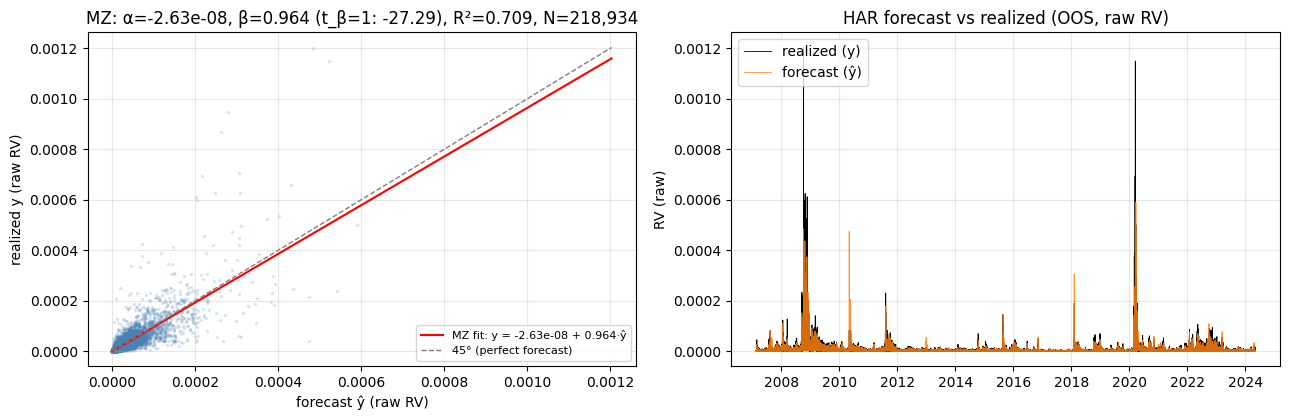

MZ calibration: alpha=-2.63e-08, beta=0.964  (optimal 0, 1)  R^2=0.709  N=218,934


In [13]:
y, yhat = preds["true_raw"].to_numpy(), preds["pred_raw"].to_numpy()
dates = pd.to_datetime(preds["date"]).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
mz = plot_mz_scatter(y, yhat, axes[0])
plot_y_yhat_timeseries(dates, y, yhat, axes[1], title="HAR forecast vs realized (OOS, raw RV)")
plt.tight_layout(); plt.show()
print(f"MZ calibration: alpha={mz['alpha']:.3g}, beta={mz['beta']:.3f}  (optimal 0, 1)  "
      f"R^2={mz['r2']:.3f}  N={mz['n']:,}")

---
### The through-line

`0.13460` was produced by the **complete set of `src/` functions shown above** — every
loader, transform primitive, scaler, scale-guard, the incremental solver (verified equal
to sklearn), and the smearing — run on the real `data/`. Nothing is read from a cached
table; nothing is a hand-picked outer wrapper. The shown code is computed by walking the
live call graph, so it stays complete and in lock-step with `src/`.

**Coverage check** (printed below): the set of defs displayed equals the transitive
`src/` closure of the pipeline entry points — proof that no working function was hidden.

In [14]:
entries = [load_and_transform, _build_har_and_calendar, _backtest_and_save, fit_predict_ridge,
           calculate_metrics, plot_mz_scatter, plot_y_yhat_timeseries]
closure = set()
for e in entries: closure.update(call_tree(e))
missing = closure - _SHOWN
print(f"src defs displayed: {len(_SHOWN)} | transitive closure: {len(closure)} | hidden: {len(missing)}")
assert not missing, sorted(f.__qualname__ for f in missing)
print("PASS - every working src function on the pipeline path is shown above.")

src defs displayed: 29 | transitive closure: 29 | hidden: 0
PASS - every working src function on the pipeline path is shown above.
